**Credit Default Prediction**
Can we predict who will default next month? Where should the lender set its cutoff?


Dataset: UCI "Default of Credit Card Clients"; 30,000 Borrowers, 22% Default Rate

After building a logistic regression baseline, I used gradient boosting to improve AUC (a measure of how well the model ranks risky borrowers above safe ones) from 0.707 to 0.775 on 30,000 credit card borrowers, and the previous month's repayment status was the largest risk driver. Assuming a default costs five times what a good loan earns, a cutoff chosen through cross-validation earned a profit of 1,256 units on held-out data, while approving everybody resulted in a loss of 1,962.

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

I loaded the UCI Default of Credit Card Clients dataset, which has 30,000 borrowers and a target column for whether they defaulted the following month (22.1% did). I checked for missing values and found none, so I didn't need to drop or fill in any rows. I renamed the columns so they're readable: the pay_ columns are repayment status codes (-1 is on time, 1 is one month late, and so on), while the bill_ and paid_ columns are dollar amounts.

In [3]:
raw = fetch_ucirepo(id=350)
df = pd.concat([raw.data.features, raw.data.targets], axis=1)

print(df.shape)
print(df.isna().sum().sum())
print(df['Y'].mean())

(30000, 24)
0
0.2212


In [4]:
df = df.rename(columns={
    'X1': 'limit', 'X2': 'sex', 'X3': 'education', 'X4': 'marriage', 'X5': 'age',
    'X6': 'pay_sep', 'X7': 'pay_aug', 'X8': 'pay_jul', 'X9': 'pay_jun',
    'X10': 'pay_may', 'X11': 'pay_apr',
    'X12': 'bill_sep', 'X13': 'bill_aug', 'X14': 'bill_jul',
    'X15': 'bill_jun', 'X16': 'bill_may', 'X17': 'bill_apr',
    'X18': 'paid_sep', 'X19': 'paid_aug', 'X20': 'paid_jul',
    'X21': 'paid_jun', 'X22': 'paid_may', 'X23': 'paid_apr',
    'Y': 'default'
})
df.head()
#wow this is so much better than going back and forth trying to figure out whats what

,limit,sex,education,marriage,age,pay_sep,pay_aug,pay_jul,pay_jun,pay_may,...,bill_jun,bill_may,bill_apr,paid_sep,paid_aug,paid_jul,paid_jun,paid_may,paid_apr,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


I looked at default rates by education level, last month's repayment status, and credit limit, and checked each group's size to see which rates were reliable. Repayment status was by far the strongest signal: borrowers who were on time defaulted about 13-17% of the time, versus 34% at one month late and 69% at two months late. Default also fell steadily as credit limit rose, from 32% in the lowest group to 14% in the highest. These are descriptive patterns, not causal ones. Lenders probably give higher limits to borrowers they already think are safe.

In [5]:
print(df.groupby('education')['default'].agg(['mean', 'count']))
print(df.groupby('pay_sep')['default'].agg(['mean', 'count']))

limit_group = pd.qcut(df['limit'], 5)
print(df.groupby(limit_group, observed=False)['default'].mean())
#chunk based on edu, larger groups provide more reliable rate, also so much faster than one by one

               mean  count
education                 
0          0.000000     14
1          0.192348  10585
2          0.237349  14030
3          0.251576   4917
4          0.056911    123
5          0.064286    280
6          0.156863     51
             mean  count
pay_sep                 
-2       0.132294   2759
-1       0.167781   5686
 0       0.128113  14737
 1       0.339479   3688
 2       0.691414   2667
 3       0.757764    322
 4       0.684211     76
 5       0.500000     26
 6       0.545455     11
 7       0.777778      9
 8       0.578947     19
limit
(9999.999, 50000.0]      0.317874
(50000.0, 100000.0]      0.257984
(100000.0, 180000.0]     0.198595
(180000.0, 270000.0]     0.168604
(270000.0, 1000000.0]    0.137966
Name: default, dtype: float64


The dataset's documentation only defines education codes 1-4 (grad school, university, high school, other), but the data also contains codes 0, 5, and 6. These are small (345 borrowers in total, about 1% of the data) and their meaning isn't documented, so I merged them into "other." This is a judgment call, and dropping those rows would also have been reasonable.

I also removed sex and marital status from the model. US lenders are legally prohibited from using them in credit decisions, so a model that relied on them couldn't be deployed. Accuracy was essentially unchanged without them (about 80.9% either way).

In [6]:
#no edu 0, 5, or 6 so just fold them into 4 ("other")
df['education'] = df['education'].replace({0: 4, 5: 4, 6: 4})

#sex and marital status cant legally be used in credit decisions, drop
df = df.drop(columns=['sex', 'marriage'])

## Preparing the data for modeling

I set aside 20% of borrowers (6,000) as a test set that the model never sees during training, and used the other 80% (24,000) to train. I used stratify so both sets keep the same default rate (about 22%), and random_state so the split is reproducible.

Education is a category stored as numeric codes, and a regression would wrongly treat those codes as a scale (as if "other" were four times "grad school"), so I converted it into yes/no columns (grad school is the reference group). I also scaled the features for logistic regression, since otherwise columns like credit limit (hundreds of thousands) would dominate columns like age. The scaler learns its means and standard deviations from the training data only, so no information from the test set leaks into training. Gradient boosting uses the unscaled data, since decision trees aren't affected by scale.

In [7]:
X = df.drop(columns=['default'])
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())


(24000, 21) (6000, 21)
0.22120833333333334 0.22116666666666668


In [8]:
X_train = pd.get_dummies(X_train, columns=['education'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['education'], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape)
#literally just learned about dummy variables in 140c cool

(24000, 23)


In [9]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
#scale everything

## Baseline: logistic regression

I started with logistic regression because it's the standard in credit modeling and its coefficients are easy to interpret. Accuracy was 80.9%, but a "model" that predicts nobody defaults gets 77.9%, so accuracy alone doesn't show the model's capacity. Area under the curve (AUC) is a better measure, since it asks how well the model ranks defaulters above non-defaulters regardless of where the cutoff is set. The baseline AUC was 0.707.

The coefficients agree with the exploration: last month's repayment status has by far the strongest positive effect on default risk, while larger recent payments and higher credit limits lower it. The `bill_` coefficients have mixed signs (for example, `bill_sep` is negative while `bill_aug` is positive). The bill columns , while independent, are highly correlated with each other, so I don't interpret them individually.

One limitation: logistic regression treats each extra month late as adding the same amount of risk, but the default rates in the exploration jump sharply at one and two months late.

In [10]:
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_s, y_train)
#fit logistic reg
#also just learned about logit vs probit in class great

LogisticRegression(max_iter=1000)

In [11]:
print('accuracy:', logit.score(X_test_s, y_test))
print('predict-nobody baseline:', 1 - y_test.mean())

probs = logit.predict_proba(X_test_s)[:, 1]
print('AUC:', roc_auc_score(y_test, probs))
#evals

accuracy: 0.8088333333333333
predict-nobody baseline: 0.7788333333333333
AUC: 0.706594393129832


In [12]:
coefs = pd.Series(logit.coef_[0], index=X_train.columns).sort_values()
print(coefs)
#all coefs

bill_sep      -0.311573
paid_sep      -0.200131
paid_aug      -0.179144
education_4   -0.146929
limit         -0.120481
education_3   -0.055205
paid_jun      -0.038667
education_2   -0.037854
paid_jul      -0.031425
paid_apr      -0.029989
paid_may      -0.021189
bill_apr      -0.013915
pay_may        0.000392
pay_apr        0.015300
bill_jun       0.037685
bill_may       0.038717
bill_jul       0.045762
pay_jun        0.058976
bill_aug       0.092064
pay_aug        0.093414
pay_jul        0.096857
age            0.100757
pay_sep        0.662468
dtype: float64


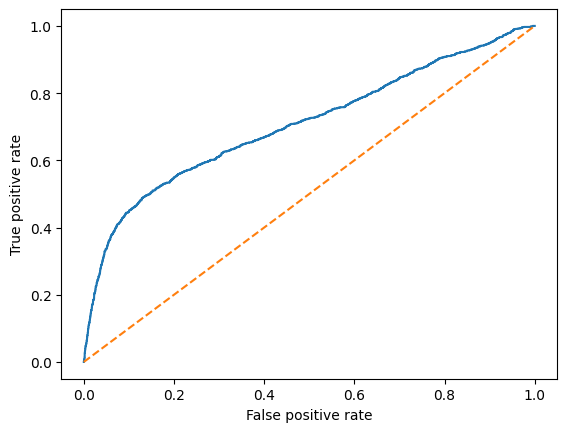

In [13]:
fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.show()
#visualize test
#thank you stack overflow

##Challenger: gradient boosting

Logistic regression only beat the "predict nobody" baseline by about 3 points of accuracy, so I tried a more flexible model. Gradient boosting builds many small decision trees in sequence, where each new tree is fit to the errors the earlier trees still make, and the final prediction combines all of them. Unlike logistic regression, it can pick up thresholds and interactions without me specifying them.

This raised AUC from 0.707 to 0.775. The ROC curves show where the gain comes from. At the high-risk end the two models are nearly identical, since borrowers who are already late are easy to spot. Gradient boosting pulls ahead in the middle range, among moderate-risk borrowers, where interactions and thresholds matter more. The tradeoff is interpretability: logistic regression gives one coefficient per feature, while gradient boosting combines many trees, which is harder to explain to customers and regulators.

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

gb_probs = gb.predict_proba(X_test)[:, 1]
print('GB AUC:', roc_auc_score(y_test, gb_probs))

GB AUC: 0.7754062161197639


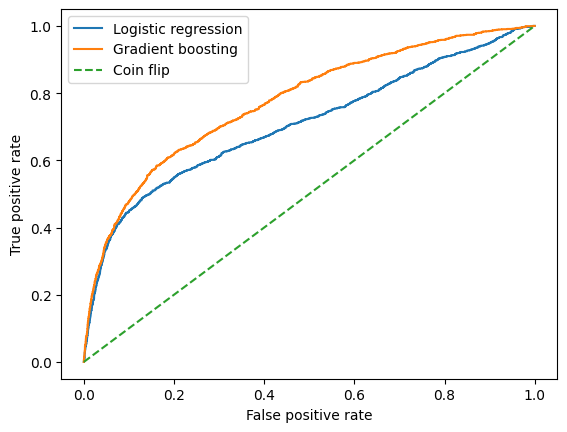

In [15]:
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)
plt.plot(fpr, tpr, label='Logistic regression')
plt.plot(fpr_gb, tpr_gb, label='Gradient boosting')
plt.plot([0, 1], [0, 1], linestyle='--', label='Coin flip')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.show()

##Evaluating at a specific cutoff

A lender has to turn a probability into a yes/no decision, so I looked at what happens at different cutoffs. At a 30% cutoff (flag anyone with a predicted default probability of 30% or more), the model caught 714 defaulters, missed 613, wrongly flagged 634 good borrowers, and correctly approved 4,039. That gives a precision of about 53% (of the borrowers flagged, about half defaulted) and a recall of about 54% (of all defaulters, about half were flagged).

Raising the cutoff to 0.5 increased accuracy, while lowering it to 0.15 decreased it. But accuracy rewards flagging fewer people, since most borrowers don't default, so it isn't a good guide to what a lender should do. In fact, the 0.15 cutoff turns out to be close to the most profitable one in the next section. Which mistakes matter more depends on what each one costs, which is what I look at next.

In [16]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

cutoff = 0.7
pred = (gb_probs >= cutoff).astype(int)

print(confusion_matrix(y_test, pred))
print('precision:', precision_score(y_test, pred))
print('recall:', recall_score(y_test, pred))

[[4593   80]
 [1077  250]]
precision: 0.7575757575757576
recall: 0.18839487565938207


## Choosing the cutoff with economics

To pick a cutoff, I assigned costs to each mistake. I assumed approving a borrower who repays earns 1 unit and approving one who defaults loses 5 units (rejected applicants earn 0). These numbers are assumptions, not from the data, which has no interest rates or loan sizes.

With these values, a borrower is worth approving when their default probability is below 1 / (1 + 5), about 0.17. Scanning cutoffs in the data gave a best cutoff of about 0.15 (a profit of about 1,259 units versus -1,962 for approving everyone). The profit curve is flat between roughly 0.15 and 0.25, so I'd treat that whole zone as an optimal are to operate in, rather than pinning down one point.

best cutoff: 0.15000000000000002 profit: 1259
approve everyone: -1962


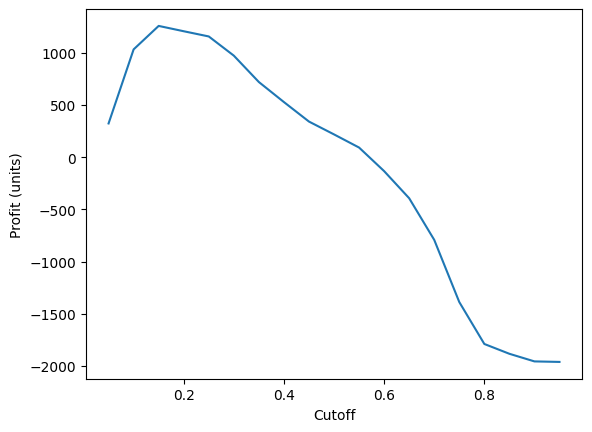

In [17]:
import numpy as np

G = 1
L = 5
actual = y_test.to_numpy()

cutoffs = np.arange(0.05, 0.96, 0.05)
profits = []

for c in cutoffs:
    approved = gb_probs < c
    good = (approved & (actual == 0)).sum()
    bad = (approved & (actual == 1)).sum()
    profits.append(G * good - L * bad)

best = cutoffs[np.argmax(profits)]
print('best cutoff:', best, 'profit:', max(profits))
print('approve everyone:', G * (actual == 0).sum() - L * (actual == 1).sum())

plt.plot(cutoffs, profits)
plt.xlabel('Cutoff')
plt.ylabel('Profit (units)')
plt.show()

## Sensitivity to the loss assumption

Because the 5:1 loss ratio is an assumption, I repeated the analysis for other values.

| Loss per default | Best cutoff | Theory | Model profit | Approve everyone |
|---|---|---|---|---|
| 2 | 0.28 | 0.33 | 2,824 | 2,019 |
| 3 | 0.26 | 0.25 | 2,258 | 692 |
| 5 | 0.14 | 0.17 | 1,284 | -1,962 |
| 10 | 0.09 | 0.09 | 439 | -8,597 |

The cutoff tightens as defaults get costlier, and the data-driven values track the theory. The model adds the most over approving everyone when defaults are expensive, but at a 10:1 loss the profit is only 439 units, so the model's rankings aren't sharp enough to build a comfortable margin on.

In [18]:
def best_cutoff(G, loss, probs, actual):
    cutoffs = np.arange(0.02, 0.96, 0.01)
    profits = []
    for c in cutoffs:
        approved = probs < c
        good = (approved & (actual == 0)).sum()
        bad = (approved & (actual == 1)).sum()
        profits.append(G * good - loss * bad)
    i = np.argmax(profits)
    return cutoffs[i], profits[i]

for loss in [2, 3, 5, 10]:
    c, p = best_cutoff(1, loss, gb_probs, actual)
    print('loss', loss, '| best cutoff', round(c, 2), '| profit', p, '| theory', round(1 / (1 + loss), 2))

loss 2 | best cutoff 0.28 | profit 2824 | theory 0.33
loss 3 | best cutoff 0.26 | profit 2258 | theory 0.25
loss 5 | best cutoff 0.14 | profit 1284 | theory 0.17
loss 10 | best cutoff 0.09 | profit 439 | theory 0.09


## An honest profit estimate

The profit above was slightly optimistic, because I chose the cutoff by looking at the same test set I then reported on. To fix this, I used 5-fold cross-validation on the training data to get predictions from models that never saw those borrowers, chose the cutoff from those (0.16), and applied it once to the untouched test set.

The test profit was 1,256 units, only about 2% below the earlier figure, so the result is stable. This is the number I report.

In [19]:
from sklearn.model_selection import cross_val_predict

cv_probs = cross_val_predict(
    HistGradientBoostingClassifier(random_state=42),
    X_train, y_train, cv=5, method='predict_proba'
)[:, 1]

actual_train = y_train.to_numpy()
c_cv, _ = best_cutoff(1, 5, cv_probs, actual_train)
print('cutoff chosen on training data:', round(c_cv, 2))

approved = gb_probs < c_cv
good = (approved & (actual == 0)).sum()
bad = (approved & (actual == 1)).sum()
print('honest test profit:', 1 * good - 5 * bad)

cutoff chosen on training data: 0.16
honest test profit: 1256


Evaluating at a specific cutoff

A lender has to turn a probability into a yes/no decision, so I looked at what happens at different cutoffs. At a 30% cutoff (flag anyone with a predicted default probability of 30% or more), the model caught 714 defaulters, missed 613, wrongly flagged 634 good borrowers, and correctly approved 4,039. That gives a precision of about 53% (of the borrowers flagged, about half defaulted) and a recall of about 54% (of all defaulters, about half were flagged).

Raising the cutoff to 0.5 increased accuracy, while lowering it to 0.15 decreased it. But accuracy rewards flagging fewer people, since most borrowers don't default, so it isn't a good guide to what a lender should do. In fact, the 0.15 cutoff turns out to be close to the most profitable one in the next section. Which mistakes matter more depends on what each one costs, which is what I look at next.

In [20]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    gb, X_test, y_test, scoring='roc_auc', n_repeats=5, random_state=42
)
imp = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(imp.head(10))

pay_sep     0.086346
bill_sep    0.020800
limit       0.018837
paid_sep    0.007981
paid_aug    0.007209
bill_jul    0.005964
pay_jul     0.005787
pay_aug     0.005626
paid_jul    0.004550
pay_apr     0.004252
dtype: float64


## Conclusion and limitations

A gradient boosting model ranked borrowers better than a logistic regression baseline (AUC 0.775 vs. 0.707), and screening with a cost-aware cutoff turned a loss from approving everyone into a profit. Repayment status in the prior month was the dominant signal.

Limitations:
- The gain and loss values are assumptions, not from the data, which is why the sensitivity table matters.
- Everyone in the data was already approved for a card, so I never see outcomes for rejected applicants (selection bias).
- The data is a single snapshot from one dataset, so I couldn't test over time, and I didn't tune the models beyond their defaults.
- I removed sex and marital status, but age and education remain in the model, and a real lender would review those for fair-lending concerns too.